# Sankey plot

> **Under development** — not published in docs. Requires GWASLab from source (`sys.path` below).

Draw a **Sankey / alluvial diagram** to show how variants flow across ordered categorical stages — for example MAF tier → P-value significance → effect-size group.

**API:** `gl.plot_sankey()` and `mysumstats.plot_sankey()`

**Prerequisites**
- Input is a `pandas.DataFrame` or loaded `Sumstats` object
- Provide **2 or more** stage names in `columns` (left → right)
- Stage names can be **built-in presets** (`MAF`, `P`, `BETA`, `STATUS`) or any existing categorical column
- Presets bin numeric GWAS columns using the same tiers as `mysumstats.summarize()` where applicable
- Returns `(fig, ax, tables)` so you can inspect `tables["nodes"]` and `tables["links"]`

## Load GWASLab

In [1]:
import sys
sys.path.insert(0, "/home/yunye/work/gwaslab/src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gwaslab as gl

%matplotlib inline

In [2]:
gl.show_version()

2026/06/12 17:23:18 GWASLab v4.1.9 https://cloufield.github.io/gwaslab/
2026/06/12 17:23:18 (C) 2022-2026, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2026/06/12 17:23:18 Python version: 3.12.0 | packaged by conda-forge | (main, Oct  3 2023, 08:43:22) [GCC 12.3.0]


## Simulated demo data

This notebook uses a synthetic GWAS-like table so it runs **fully offline** (no sample download). The table has 5,000 variants with `EAF`, `P`, and `BETA` columns in GWASLab reserved-header style.

In [3]:
rng = np.random.default_rng(42)
n = 5000

demo_df = pd.DataFrame({
    "SNPID": [f"rs{i}" for i in range(n)],
    "CHR": rng.integers(1, 23, size=n),
    "POS": rng.integers(1_000_000, 100_000_000, size=n),
    "EA": "A",
    "NEA": "G",
    "EAF": rng.beta(0.4, 4.0, size=n),
    "P": 10 ** (-rng.uniform(4, 12, size=n)),
    "BETA": rng.normal(0, 0.15, size=n),
})

mysumstats = gl.Sumstats(
    sumstats=demo_df,
    snpid="SNPID",
    chrom="CHR",
    pos="POS",
    ea="EA",
    nea="NEA",
    eaf="EAF",
    p="P",
    beta="BETA",
    build="19",
    verbose=False,
)

mysumstats.data.head()

,SNPID,CHR,POS,EA,NEA,STATUS,EAF,BETA,P
0,rs0,2,20588939,A,G,1999999,0.000001,0.146086,8.831813e-12
1,rs1,18,4353901,A,G,1999999,0.278962,-0.095877,3.224473e-06
2,rs2,15,63103712,A,G,1999999,0.005152,-0.086954,6.538604e-08
3,rs3,10,68618480,A,G,1999999,0.006884,-0.117508,1.485189e-05
4,rs4,10,77488918,A,G,1999999,0.010939,0.285993,1.464172e-06


## Example: overall disease vs subtype signals → MAF

Simulate a **multi-trait** setting: one overall-disease GWAS plus three subtype scans (A/B/C). Each variant is labeled by overall significance and subtype overlap, then linked to MAF tiers.

| Column | Meaning |
|--------|---------|
| `overall_signal` | GW-significant / suggestive / non-significant for overall disease |
| `subtype_signal` | Shared across subtypes, subtype-specific hit, suggestive, or none |
| `MAF` | preset binning from `EAF` |

Ribbons are colored by **overall signal** (`color_by="first"`), so you can see how overall GW hits flow into subtype patterns and MAF strata.

In [4]:
from sankey_demo_fixtures import (
    OVERALL_SIGNAL_ORDER,
    SUBTYPE_SIGNAL_ORDER,
    overall_signal_colors,
    simulate_disease_subtype_sumstats,
)

disease_df = simulate_disease_subtype_sumstats(n_variants=6000, seed=42)

disease_ss = gl.Sumstats(
    sumstats=disease_df,
    snpid="SNPID",
    chrom="CHR",
    pos="POS",
    ea="EA",
    nea="NEA",
    eaf="EAF",
    p="P",
    beta="BETA",
    build="19",
    verbose=False,
)

disease_df[["overall_signal", "subtype_signal", "EAF"]].head()

,overall_signal,subtype_signal,EAF
0,Overall suggestive,Multiple subtypes,0.102105
1,Overall GW significant,Subtype C only,0.000344
2,Overall GW significant,Multiple subtypes,0.000563
3,Overall GW significant,Multiple subtypes,0.065227
4,Overall GW significant,Multiple subtypes,0.035775


Overall signal counts:
overall_signal
Overall GW significant     3387
Overall suggestive         1550
Overall non-significant    1063
Name: count, dtype: int64

Subtype signal counts:
subtype_signal
Multiple subtypes     3456
Subtype A only         699
Subtype B only         665
Subtype C only         615
Subtype suggestive     524
No subtype signal       41
Name: count, dtype: int64


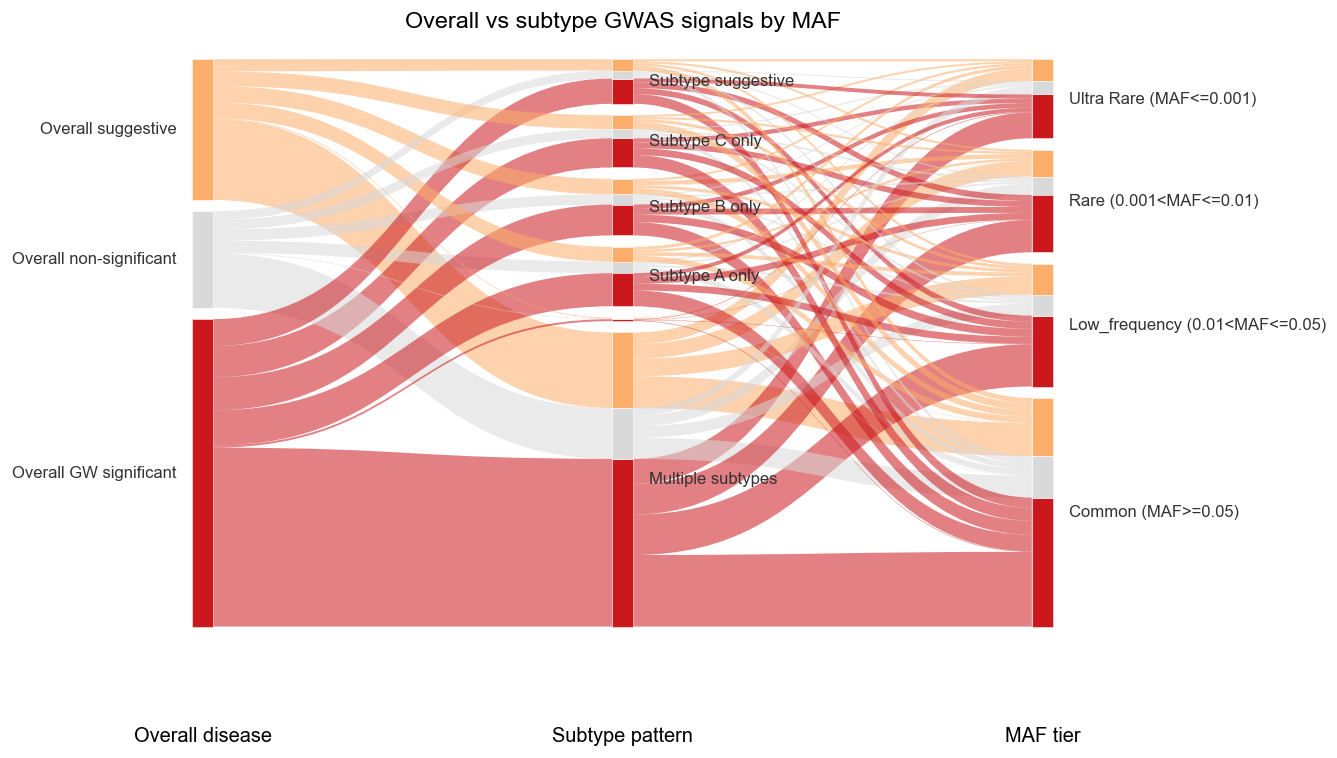

In [5]:
print("Overall signal counts:")
print(disease_df["overall_signal"].value_counts().reindex(OVERALL_SIGNAL_ORDER).fillna(0).astype(int))
print("\nSubtype signal counts:")
print(disease_df["subtype_signal"].value_counts().reindex(SUBTYPE_SIGNAL_ORDER).fillna(0).astype(int))

fig, ax, disease_tables = disease_ss.plot_sankey(
    columns=["overall_signal", "subtype_signal", "MAF"],
    stage_labels=["Overall disease", "Subtype pattern", "MAF tier"],
    color_by="first",
    palette="auto",
    node_color_mode="stacked",
    colors=overall_signal_colors(),
    title="Overall vs subtype GWAS signals by MAF",
    fig_kwargs={"figsize": (13, 7), "dpi": 120},
    link_alpha=0.55,
    verbose=False,
)
fig

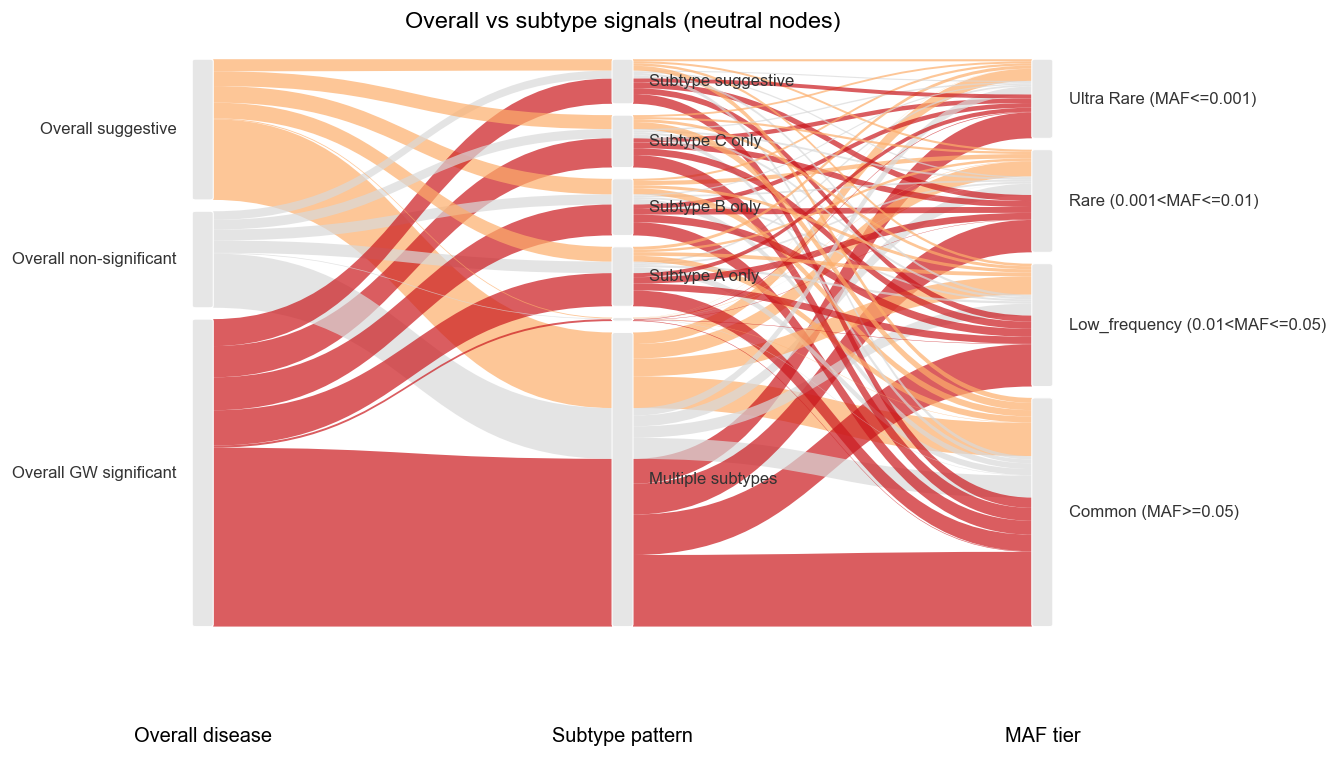

In [6]:
# Publication-style view: gray nodes, stronger ribbons
fig, ax, _ = gl.plot_sankey(
    disease_df,
    columns=["overall_signal", "subtype_signal", "MAF"],
    stage_labels=["Overall disease", "Subtype pattern", "MAF tier"],
    colors=overall_signal_colors(),
    node_color_mode="neutral",
    link_alpha=0.7,
    title="Overall vs subtype signals (neutral nodes)",
    fig_kwargs={"figsize": (13, 7), "dpi": 120},
    verbose=False,
)
plt.show()

### Built-in presets

| Preset | Source column | Categories |
|--------|---------------|------------|
| `MAF` | `EAF` (minor allele frequency) | Common ≥0.05; Low freq; Rare; Ultra rare |
| `P` | `P` | P<5e-8; P<5e-6; Non-significant |
| `BETA` | `BETA` | \|BETA\|>0.3, >0.1, >0.05, or Small |

Preset names take priority over same-named columns, so `columns=["MAF", "P", "BETA"]` bins numeric fields instead of plotting raw values.

In [7]:
fig, ax, tables = mysumstats.plot_sankey(
    columns=["MAF", "P", "BETA"],
    stage_labels=["MAF tier", "Significance", "Effect size"],
    title="Variant flow: MAF → P → |BETA|",
    fig_kwargs={"figsize": (12, 7), "dpi": 120},
    verbose=True,
)
plt.show()

2026/06/12 17:23:19 Start to create Sankey plot...
2026/06/12 17:23:19  -Stages: ['MAF', 'P', 'BETA']
2026/06/12 17:23:19  -Color by: first
2026/06/12 17:23:19 Configured plot style for plot_sankey:None
2026/06/12 17:23:19 Start to save figure...
2026/06/12 17:23:19  -Skip saving figure!
2026/06/12 17:23:19 Finished saving figure...
2026/06/12 17:23:19 Finished creating Sankey plot.


## Inspect node and link tables

The third return value is a dict with aggregated layout tables. Use these for custom summaries or export.

In [8]:
tables["nodes"].head(10)

,node_id,stage_idx,stage_name,category,value,x,y0,y1
0,MAF|Common (MAF>=0.05),0,MAF,Common (MAF>=0.05),2237.0,0.0,0.000000,0.420556
1,MAF|Low_frequency (0.01<MAF<=0.05),0,MAF,Low_frequency (0.01<MAF<=0.05),1231.0,0.0,0.440556,0.671984
2,MAF|Rare (0.001<MAF<=0.01),0,MAF,Rare (0.001<MAF<=0.01),918.0,0.0,0.691984,0.864568
3,MAF|Ultra Rare (MAF<=0.001),0,MAF,Ultra Rare (MAF<=0.001),614.0,0.0,0.884568,1.000000
4,P|P<5e-8,1,P,P<5e-8,2986.0,0.5,0.426688,1.000000
5,P|P<5e-6,1,P,P<5e-6,1234.0,0.5,0.169760,0.406688
6,P|Non-significant,1,P,Non-significant,780.0,0.5,0.000000,0.149760
7,BETA||BETA|>0.05,2,BETA,|BETA|>0.05,3659.0,1.0,0.282836,1.000000
8,BETA|Small,2,BETA,Small,1341.0,1.0,0.000000,0.262836


In [9]:
tables["links"].head(10)

,source,target,value,color_key,flow_id,stage_from,stage_to,sy0,sy1,ty0,ty1
0,MAF|Ultra Rare (MAF<=0.001),P|P<5e-8,358.0,Ultra Rare (MAF<=0.001),Ultra Rare (MAF<=0.001)|MAF|Ultra Rare (MAF<=0...,0,1,0.932696,1.000000,0.931264,1.000000
1,MAF|Common (MAF>=0.05),P|P<5e-6,544.0,Common (MAF>=0.05),Common (MAF>=0.05)|MAF|Common (MAF>=0.05)|P|P<...,0,1,0.064108,0.166380,0.169760,0.274208
2,MAF|Rare (0.001<MAF<=0.01),P|P<5e-6,227.0,Rare (0.001<MAF<=0.01),Rare (0.001<MAF<=0.01)|MAF|Rare (0.001<MAF<=0....,0,1,0.718304,0.760980,0.331616,0.375200
3,MAF|Rare (0.001<MAF<=0.01),P|Non-significant,140.0,Rare (0.001<MAF<=0.01),Rare (0.001<MAF<=0.01)|MAF|Rare (0.001<MAF<=0....,0,1,0.691984,0.718304,0.105216,0.132096
4,MAF|Low_frequency (0.01<MAF<=0.05),P|P<5e-6,299.0,Low_frequency (0.01<MAF<=0.05),Low_frequency (0.01<MAF<=0.05)|MAF|Low_frequen...,0,1,0.479472,0.535684,0.274208,0.331616
5,MAF|Common (MAF>=0.05),P|P<5e-8,1352.0,Common (MAF>=0.05),Common (MAF>=0.05)|MAF|Common (MAF>=0.05)|P|P<...,0,1,0.166380,0.420556,0.426688,0.686272
6,MAF|Low_frequency (0.01<MAF<=0.05),P|P<5e-8,725.0,Low_frequency (0.01<MAF<=0.05),Low_frequency (0.01<MAF<=0.05)|MAF|Low_frequen...,0,1,0.535684,0.671984,0.686272,0.825472
7,MAF|Common (MAF>=0.05),P|Non-significant,341.0,Common (MAF>=0.05),Common (MAF>=0.05)|MAF|Common (MAF>=0.05)|P|No...,0,1,0.000000,0.064108,0.000000,0.065472
8,MAF|Low_frequency (0.01<MAF<=0.05),P|Non-significant,207.0,Low_frequency (0.01<MAF<=0.05),Low_frequency (0.01<MAF<=0.05)|MAF|Low_frequen...,0,1,0.440556,0.479472,0.065472,0.105216
9,MAF|Rare (0.001<MAF<=0.01),P|P<5e-8,551.0,Rare (0.001<MAF<=0.01),Rare (0.001<MAF<=0.01)|MAF|Rare (0.001<MAF<=0....,0,1,0.760980,0.864568,0.825472,0.931264


## Refined coloring (first-stage flow)

By default, ribbons and node bands are colored by the **first column** (`color_by="first"`). Each MAF tier keeps its hue across P and BETA stages. Preset stage 0 uses semantic palettes (MAF blues, P gray→red, BETA gray→purple).

- `node_color_mode="stacked"` — colored bands inside each node bar (default)
- `node_color_mode="neutral"` — gray nodes; color only on ribbons
- `colors={...}` — override a first-stage category or full `node_id`

In [10]:
fig, ax, tables = mysumstats.plot_sankey(
    columns=["MAF", "P", "BETA"],
    color_by="first",
    palette="auto",
    node_color_mode="stacked",
    title="Stacked bands (default refined coloring)",
    fig_kwargs={"figsize": (12, 7), "dpi": 120},
    verbose=False,
)
plt.show()

print("Flow colors:", tables["flow_colors"])

Flow colors: {'Common (MAF>=0.05)': '#08519C', 'Low_frequency (0.01<MAF<=0.05)': '#3182BD', 'Rare (0.001<MAF<=0.01)': '#6BAED6', 'Ultra Rare (MAF<=0.001)': '#DEEBF7'}


In [11]:
fig, ax, tables = mysumstats.plot_sankey(
    columns=["MAF", "P", "BETA"],
    node_color_mode="neutral",
    link_alpha=0.65,
    colors={"Common (MAF>=0.05)": "#1B9E77"},
    title="Neutral nodes + custom Common MAF color",
    fig_kwargs={"figsize": (12, 7), "dpi": 120},
    verbose=False,
)
plt.show()

## User-defined categorical columns

Add your own grouping columns (e.g. annotation subtype, locus class) and mix them with presets. Non-preset names must already exist on `mysumstats.data`.

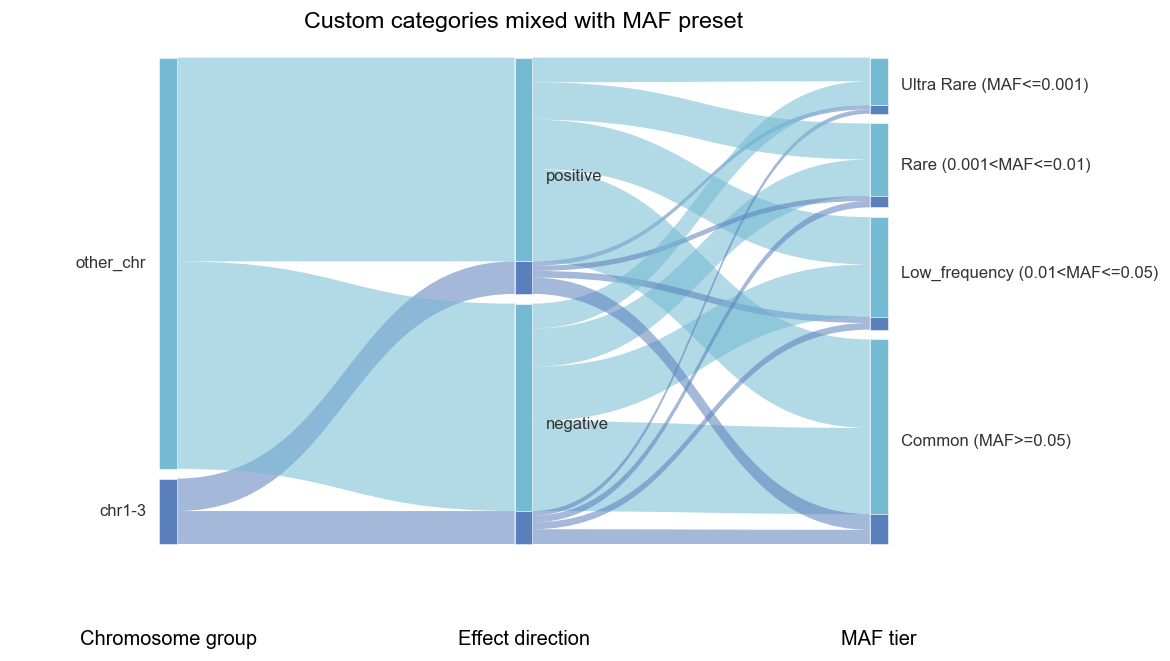

In [12]:
work = mysumstats.data.copy()
work["chr_class"] = np.where(work["CHR"].isin([1, 2, 3]), "chr1-3", "other_chr")
work["effect_dir"] = np.where(work["BETA"] >= 0, "positive", "negative")

fig, ax, tables = gl.plot_sankey(
    work,
    columns=["chr_class", "effect_dir", "MAF"],
    stage_labels=["Chromosome group", "Effect direction", "MAF tier"],
    title="Custom categories mixed with MAF preset",
    fig_kwargs={"figsize": (11, 6), "dpi": 120},
    verbose=False,
)
plt.show()

## Two-stage plot and save

A Sankey needs at least two stages. Pass `save=` to write PNG/PDF via GWASLab's `save_figure` helper.

2026/06/12 17:23:19 Start to create Sankey plot...
2026/06/12 17:23:19  -Stages: ['MAF', 'P']
2026/06/12 17:23:19  -Color by: first
2026/06/12 17:23:19 Configured plot style for plot_sankey:None
2026/06/12 17:23:19 Start to save figure...
2026/06/12 17:23:19  -Saved to sankey_maf_p_demo.png successfully! (png) (overwrite)
2026/06/12 17:23:19 Finished saving figure...
2026/06/12 17:23:19 Finished creating Sankey plot.


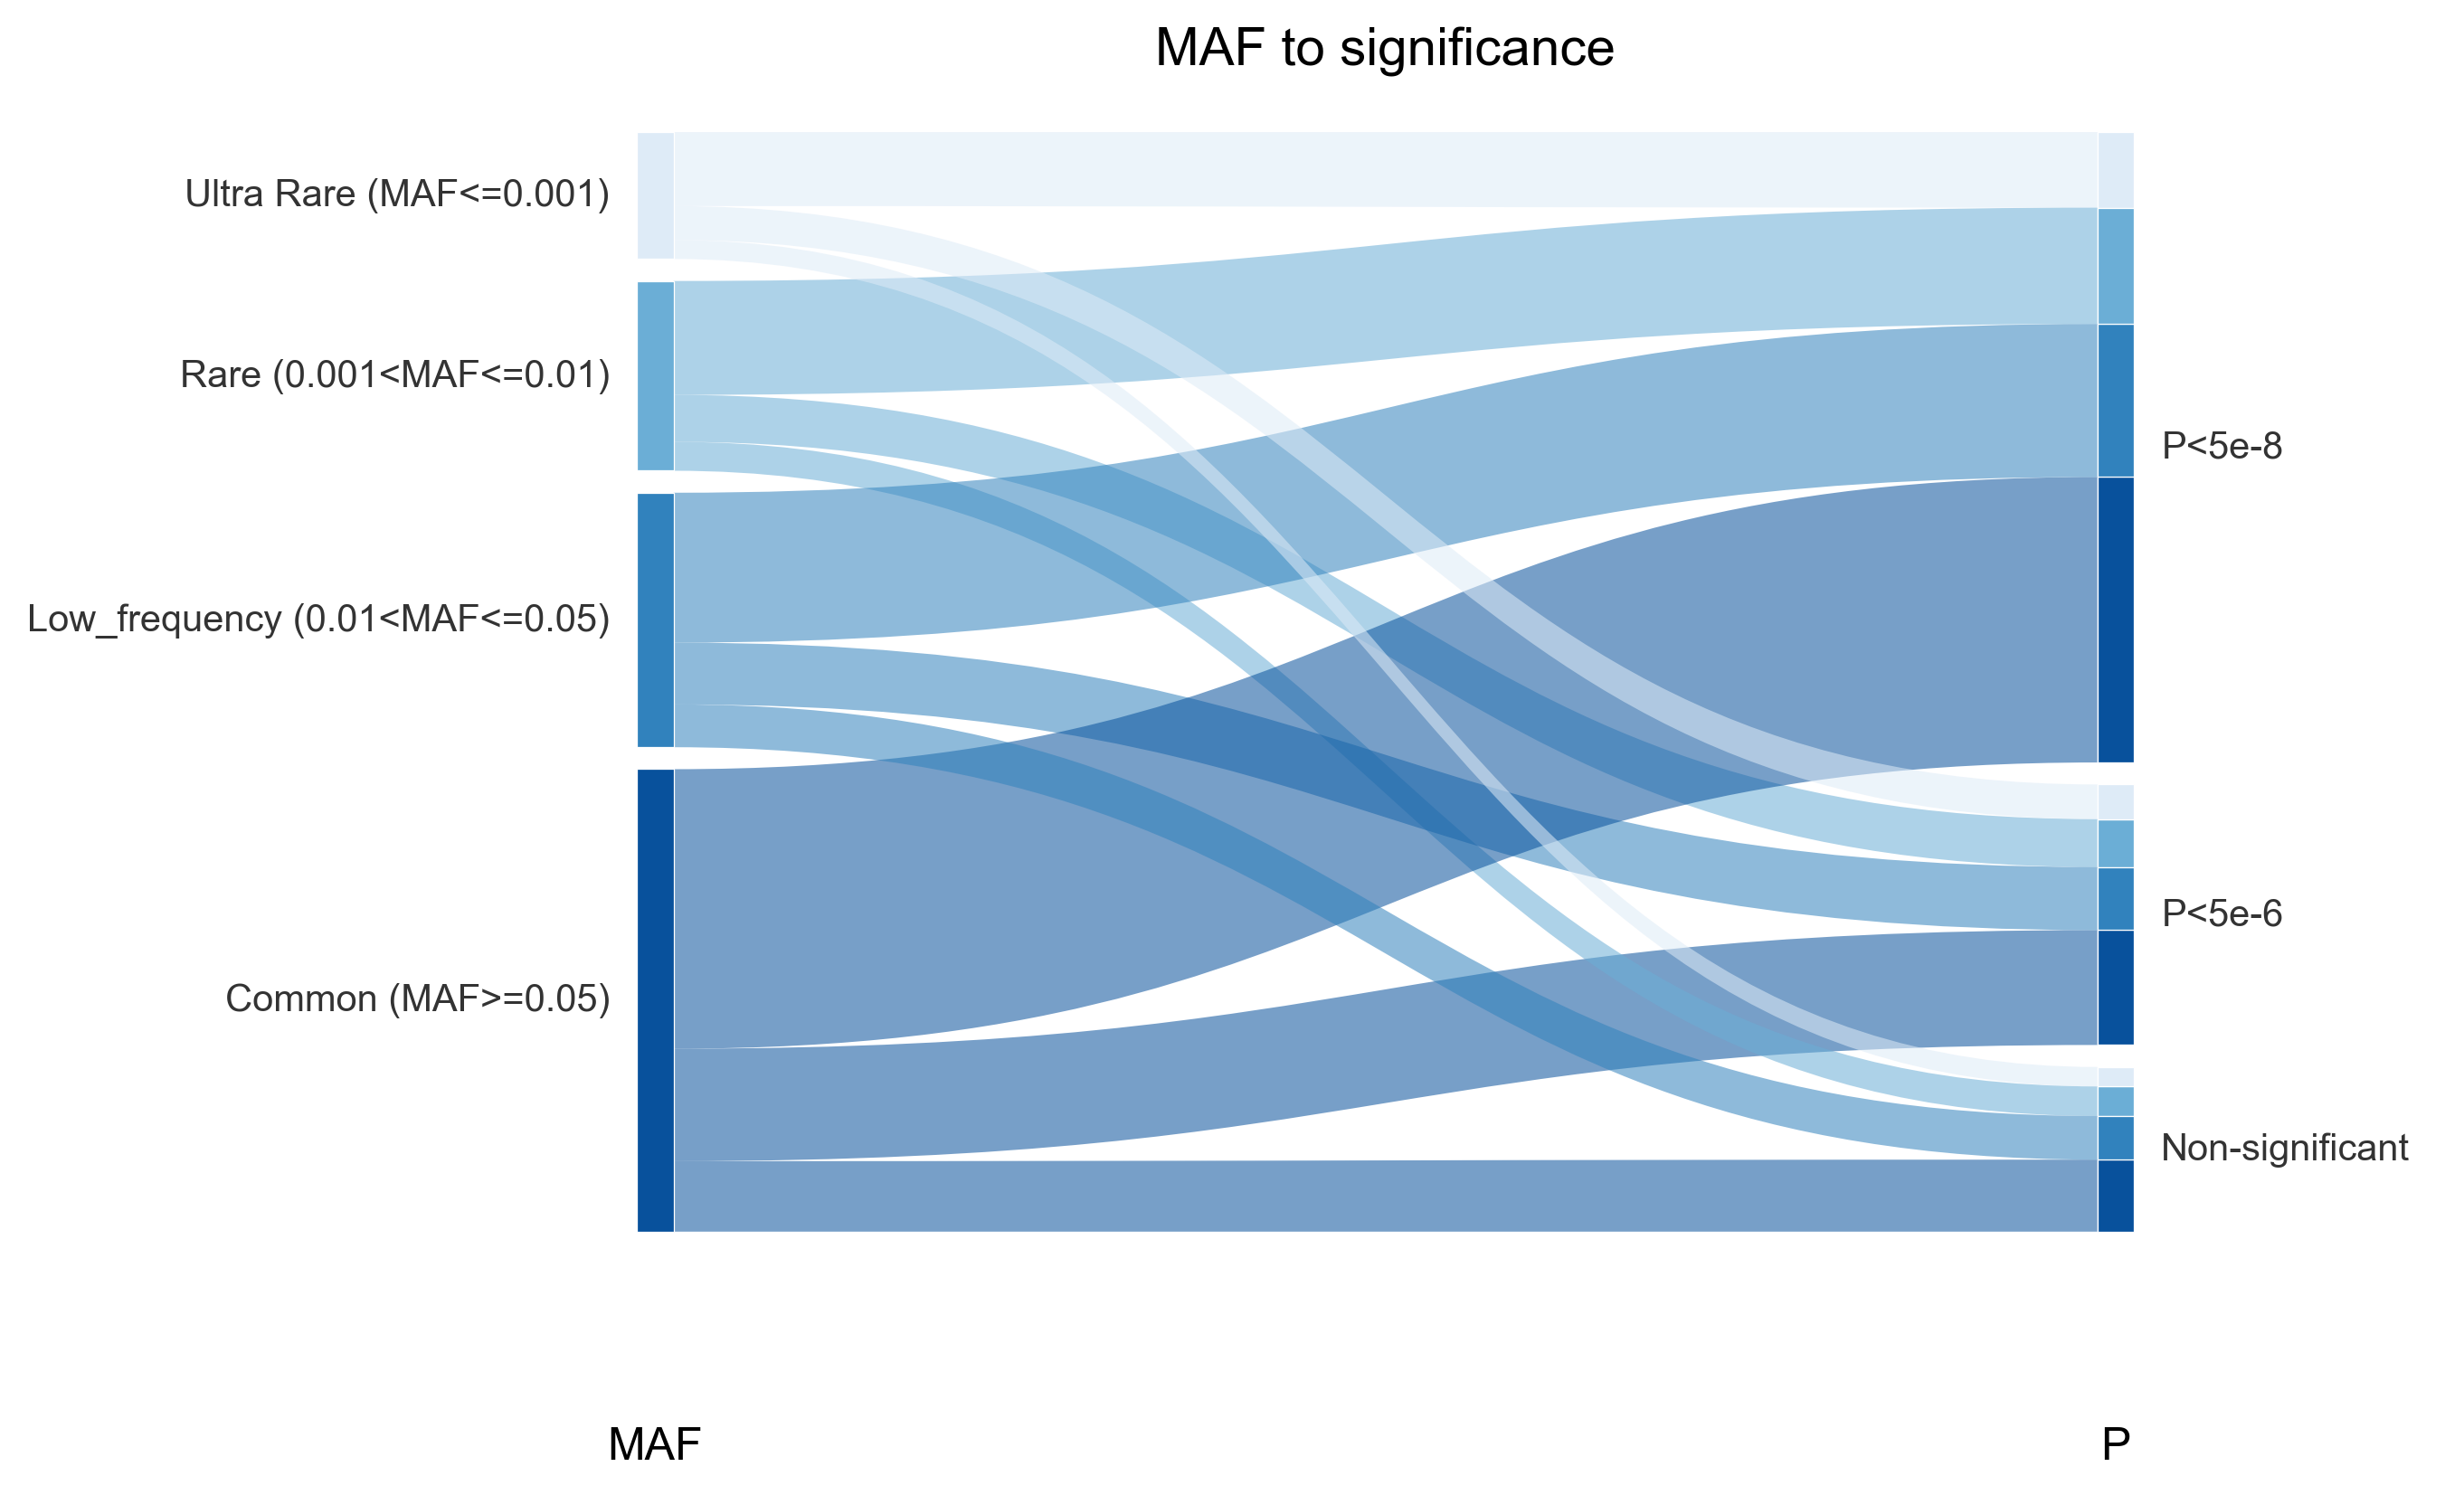

In [13]:
fig, ax, tables = gl.plot_sankey(
    mysumstats,
    columns=["MAF", "P"],
    title="MAF to significance",
    save="sankey_maf_p_demo.png",
    save_kwargs={"dpi": 200, "facecolor": "white"},
    verbose=True,
)
plt.show()

2026/06/12 17:24:35 Start to create Sankey plot...
2026/06/12 17:24:35  -Stages: ['MAF', 'P', 'BETA']
2026/06/12 17:24:35  -Color by: first
2026/06/12 17:24:35 Configured plot style for plot_sankey:None
2026/06/12 17:24:35 Start to save figure...
2026/06/12 17:24:35  -Skip saving figure!
2026/06/12 17:24:35 Finished saving figure...
2026/06/12 17:24:35 Finished creating Sankey plot.


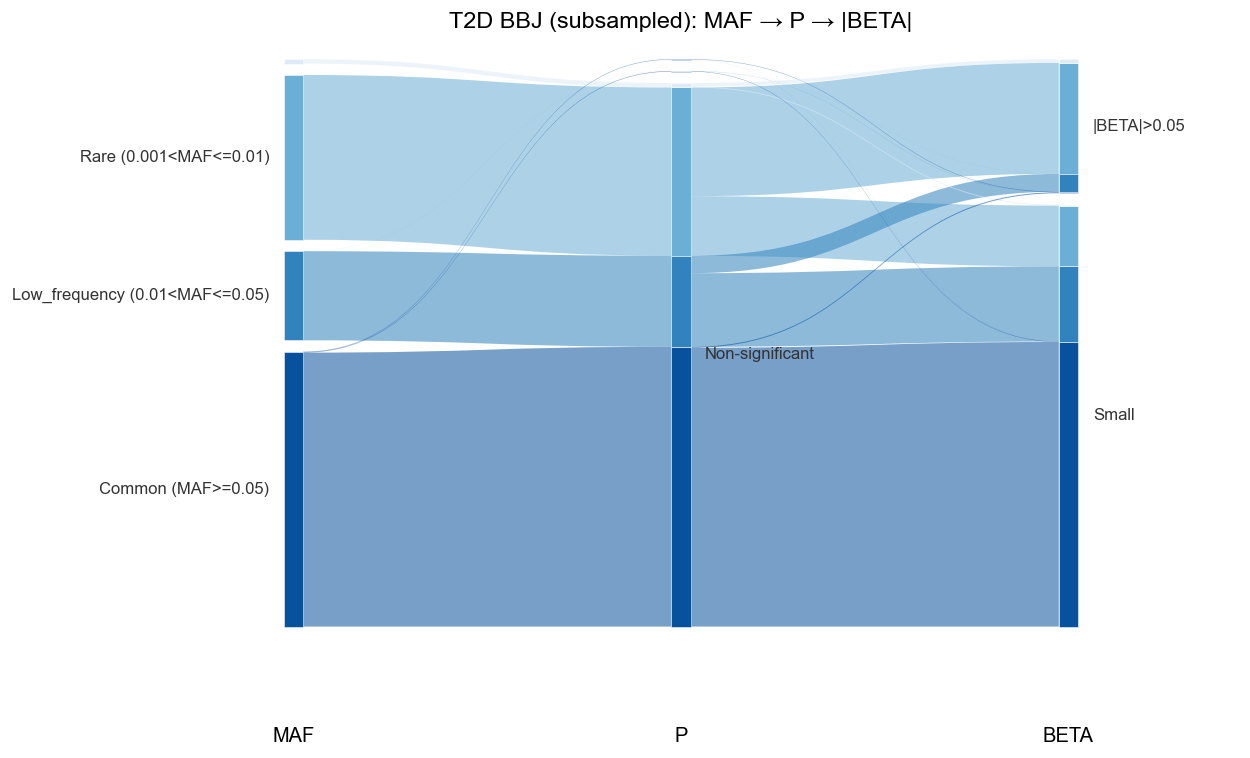

In [16]:
from pathlib import Path

bbj_path = Path("../../0_sample_data/t2d_bbj.txt.gz")
if bbj_path.exists():
    t2d = gl.Sumstats(
        str(bbj_path),
        snpid="SNP",
        chrom="CHR",
        pos="POS",
        ea="ALT",
        nea="REF",
        beta="BETA",
        eaf="Frq",
        se="SE",
        p="P",
        build="19",
        verbose=False,
    )
    # Subsample for a faster demo plot
    t2d_sub = t2d.data.sample(n=min(20_000, len(t2d.data)), random_state=0)
    fig, ax, tables = gl.plot_sankey(
        t2d_sub,
        columns=["MAF", "P", "BETA"],
        title="T2D BBJ (subsampled): MAF → P → |BETA|",
        fig_kwargs={"figsize": (12, 7), "dpi": 120},
        verbose=True,
    )
    plt.show()
else:
    print(f"Skip real-data demo — file not found: {bbj_path.resolve()}")
    print("Run: bash examples/0_sample_data/download_sample_data.sh")